# STAT 207 Group Lab Assignment 13 - [10 total points]

## Measuring Model Performance & Model Searching

<hr>

## <u>Lab Grading</u>:

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

my submission is under netID rjguhl2

If you said **my submission is under netID** above, we will not read any more of your lab submission.

If you said **grade this submission** above, who worked with you on this submission?  Write both their **names** and **netIDs**.  

Also, discuss and record if you've ever been on a cruise before.

## <u>Purpose</u>:
You should work in groups of 2-3 on this report (not working in groups without permission will result in a point deduction). The purpose of this group lab assignment is to assess model fit and overfitting through model searching.
<hr>

### Group Roles

Suggested and specified roles are provided below: 

#### Groups of 2

* **Driver**: This student will type the report.  While typing the report, you may be the one who is selecting the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  Specific ways to help may include: outlining the general steps needed to solve a question (providing the overview), locating examples within the course notes, and reviewing each line of code as it is typed.

#### Groups of 3

* **Driver**: This student will type the report.  They may also be the one to select the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  They may select the general approach to answering the question and/or a few steps to be completed along the way. 
* **Communicator**: This student will review the report (as it is typed) to ensure that it is clear and concise.  This student may also locate relevant examples within the course notes that may help complete the assignment.

<hr>

### Imports

In [75]:
#Run this
import pandas as pd                    # imports pandas and calls the imported version 'pd'
import matplotlib.pyplot as plt        # imports the package and calls it 'plt'
import seaborn as sns                  # imports the seaborn package with the imported name 'sns'
sns.set()  
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

## Case Study: Crew Size on Cruise Ships

We will look at data collected about the size of a crew (in hundreds) on cruise ships.  In particular, we would like to be able to predict the size of the crew needed for a cruise ship from other characteristics about that ship.  The original data can be found here: https://github.com/bot13956/ML_Model_for_Predicting_Ships_Crew_Size/blob/master/cruise_ship_info.csv.

For this case study, we will consider the following variables:

- **Age**: the age of the ship (years)
- **Tonnage**: the amount of water the ship displaces
- **passengers**: the max number of passengers the ship can hold (in 100s)
- **length**: the length of the ship (in hundrds of feet)
- **cabins**: the number of cabins (in 100s)
- **passenger_density**: a space ratio for how much space is on board per passenger
- **crew**: the number of crew members on the ship (in 100s)

The code cell below will read in the data for you and create a test and training set.  Be sure to run the cell. 

In [76]:
df = pd.read_csv('cruise_ship_info.csv')
df_train, df_test = train_test_split(df, test_size = 0.2, random_state = 41724)

### 1. [4 points] Searching for a Good Model

**a)** Perform forward selection using the adjusted $R^2$ ($R^2_\text{adj}$) as your metric on your training data.

In [77]:
current_best_model = smf.ols(formula='crew~Age', data=df_train).fit()
print(current_best_model.summary())
print(f'Age R-Squared Adjusted: {current_best_model.rsquared_adj}')

                            OLS Regression Results                            
Dep. Variable:                   crew   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     44.19
Date:                Wed, 20 Nov 2024   Prob (F-statistic):           8.47e-10
Time:                        11:40:33   Log-Likelihood:                -307.65
No. Observations:                 126   AIC:                             619.3
Df Residuals:                     124   BIC:                             625.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.1307      0.566     19.649      0.0

In [78]:
current_best_model = smf.ols(formula='crew~Tonnage', data=df_train).fit()
print(current_best_model.summary())
print(f'Tonnage R-Squared Adjusted: {current_best_model.rsquared_adj}')

                            OLS Regression Results                            
Dep. Variable:                   crew   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     753.6
Date:                Wed, 20 Nov 2024   Prob (F-statistic):           1.57e-54
Time:                        11:40:33   Log-Likelihood:                -203.57
No. Observations:                 126   AIC:                             411.1
Df Residuals:                     124   BIC:                             416.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8312      0.242      7.574      0.0

In [79]:
current_best_model = smf.ols(formula='crew~passengers', data=df_train).fit()
print(current_best_model.summary())
print(f'passengers R-Squared Adjusted: {current_best_model.rsquared_adj}')

                            OLS Regression Results                            
Dep. Variable:                   crew   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     645.5
Date:                Wed, 20 Nov 2024   Prob (F-statistic):           5.49e-51
Time:                        11:40:33   Log-Likelihood:                -211.85
No. Observations:                 126   AIC:                             427.7
Df Residuals:                     124   BIC:                             433.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8970      0.258      7.345      0.0

In [80]:
current_best_model = smf.ols(formula='crew~length', data=df_train).fit()
print(current_best_model.summary())
print(f'length R-Squared Adjusted: {current_best_model.rsquared_adj}')

                            OLS Regression Results                            
Dep. Variable:                   crew   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     707.0
Date:                Wed, 20 Nov 2024   Prob (F-statistic):           4.63e-53
Time:                        11:40:33   Log-Likelihood:                -207.01
No. Observations:                 126   AIC:                             418.0
Df Residuals:                     124   BIC:                             423.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.9592      0.528    -11.292      0.0

In [81]:
current_best_model = smf.ols(formula='crew~cabins', data=df_train).fit()
print(current_best_model.summary())
print(f'cabins R-Squared Adjusted: {current_best_model.rsquared_adj}')

                            OLS Regression Results                            
Dep. Variable:                   crew   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     1254.
Date:                Wed, 20 Nov 2024   Prob (F-statistic):           1.09e-66
Time:                        11:40:33   Log-Likelihood:                -175.16
No. Observations:                 126   AIC:                             354.3
Df Residuals:                     124   BIC:                             360.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3178      0.202      6.538      0.0

In [82]:
current_best_model = smf.ols(formula='crew~passenger_density', data=df_train).fit()
print(current_best_model.summary())
print(f'passenger_density R-Squared Adjusted: {current_best_model.rsquared_adj}')

                            OLS Regression Results                            
Dep. Variable:                   crew   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     2.236
Date:                Wed, 20 Nov 2024   Prob (F-statistic):              0.137
Time:                        11:40:33   Log-Likelihood:                -325.73
No. Observations:                 126   AIC:                             655.5
Df Residuals:                     124   BIC:                             661.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             9.7772      1.38

In [83]:
current_best_model = smf.ols(formula='crew~cabins+length+passengers+Age', data=df_train).fit()
print(current_best_model.summary())
print(f'Age R-Squared Adjusted: {current_best_model.rsquared_adj}')

                            OLS Regression Results                            
Dep. Variable:                   crew   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     453.8
Date:                Wed, 20 Nov 2024   Prob (F-statistic):           8.15e-72
Time:                        11:40:33   Log-Likelihood:                -152.18
No. Observations:                 126   AIC:                             314.4
Df Residuals:                     121   BIC:                             328.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3776      0.601     -2.292      0.0

**b)** Briefly summarize the results of this selection process.  Be sure to answer:
- What was your starting model?
- What was the most important initial variable to add to the model?
- What was your final model?
- What was the $R^2_\text{adj}$ of your final model?

- Linear Regression
- Cabins
- Cabins, length, passengers, and age
- 0.935

### 2. [2.5 points]  Check for Multicollinearity

**a)** Now, check your model that you selected in Question 1 after forward selection for multicollinearity.  You may use either a visualization or summary statistics to check.

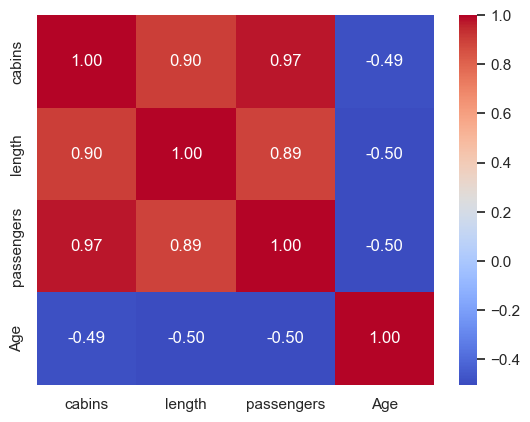

In [84]:
correlation_matrix = df_train[['cabins', 'length', 'passengers', 'Age']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

**b)** Based on what you see from part a, determine if or how you might want to change your model to reduce multicollinearity.  Briefly explain any changes that you'd like to make to the model.  Then, fit a new model to the training data using your selected predictors.

*Note*: there is not a single correct answer here.  We are hoping that you make a reasonable choice based on your current understanding.

*Second note*: If you are satisfied with your current model for multicollinearity, pick the least important predictor to remove from the model, and fit an updated model to the training data with your selected predictors.

In order to reduce multicollinearity, it would be better to reduce the number of variables we use and choose the comibination with the least multicollinearity, which in this cause, would be cabins and Age.

In [85]:
new_current_best_model = smf.ols(formula='crew~cabins+Age', data=df_train).fit()
print(current_best_model.summary())
print(f'R-Squared Adjusted: {current_best_model.rsquared_adj}')

                            OLS Regression Results                            
Dep. Variable:                   crew   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     453.8
Date:                Wed, 20 Nov 2024   Prob (F-statistic):           8.15e-72
Time:                        11:40:33   Log-Likelihood:                -152.18
No. Observations:                 126   AIC:                             314.4
Df Residuals:                     121   BIC:                             328.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3776      0.601     -2.292      0.0

### 3. [3.5 points] Comparing Our Two Models for Overfitting

We now have two candidate models: our model from forward selection in Question 1 and our reduced model from Question 2.  In this question, we'll aim to identify which model performs better on *new* data.

**a)** Calculate the $RMSE$ for each of our two models on each of our two data sets: the training and the test set.  Be sure that you use the same original model for both calculations (that is, you don't need to re-fit a second version of your model to your test data).

In [86]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
np.sqrt(mean_squared_error(df_train['crew'], current_best_model.predict(df_train)))

0.8096521284958936

In [87]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
np.sqrt(mean_squared_error(df_test['crew'], current_best_model.predict(df_test)))

1.4797389405245753

In [88]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
np.sqrt(mean_squared_error(df_train['crew'], new_current_best_model.predict(df_train)))

0.9580562970115235

In [89]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
np.sqrt(mean_squared_error(df_test['crew'], new_current_best_model.predict(df_test)))

1.4272454641765404

**b)** Based on these results, which model would you prefer?  Briefly explain how you picked the model that you prefer.  That is, what is the criteria that you used to select your model preference?

Since the gap between the test and the RMSE train sets is high, this shows overfitting.

**c)** What are the ideal characteristics of the model that we selected in part **b**?  

Note that we are asking you to explain the underlying meaning or reason behind your model selection.  In other words, in part **b** you selected a model based on an appropriate criteria.  Now, we are asking you to explain what that criteria means or indicates about your model.

We want a small gap between the training and testing data RMSE to prove that there is little to no overfitting in the mode. Furthermore we are also looking for a lower test RMSE generally which means the model is more consistent and not just focused on the training set.